In [2]:
import numpy as np
import matplotlib.pyplot as plt

from Environment.geometry import GeometrySpace
from Environment.env_class import ParamSpace
from Environment.flags import SphericalFlag, EdgeFlag2D, SphericalTaperingFlag
from Physics.calculate_pressure import calculate_pressure
from Physics.calculate_conc import calculate_concentrations
from Util.evaluate_function import evaluate_env


# Load and prepare the data

In [12]:
# Load the simulation data
xx = np.load("./Data/radial_xx.npy")
tt = np.load("./Data/radial_tt.npy")
C_N = np.load("./Data/radial_C_N.npy")
C_F = np.load("./Data/radial_C_F.npy")
C_INT = np.load("./Data/radial_C_INT.npy")

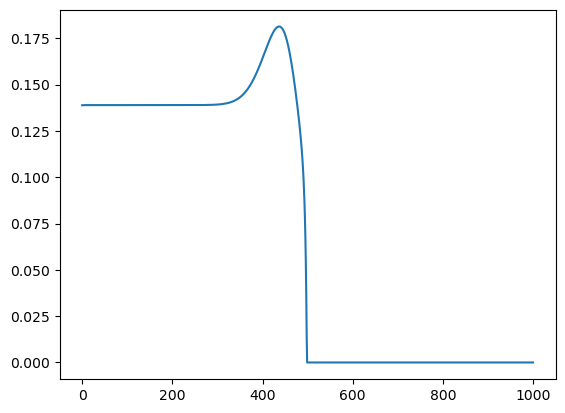

In [13]:
plt.plot(C_N[-1, :])

In [14]:
# Select the last time step for each concentration
C_N = C_N[-1, :]#[-1, :]
C_F = C_F[-1, :]
C_INT = C_INT[-1, :]

xx = xx[-1, :]
tt = tt[-1, :]

# Compute pressure and prepare operators

In [ ]:
test_geo = GeometrySpace(2.0, 0, 0, 0.002, 0.005, 72000)

test = ParamSpace(test_geo)


test.open_params("./Config/sim_params.json")


test.add_flag(SphericalFlag([0.0], 1.0), "tumor")
test.add_flag(SphericalFlag([2.0], 1.0), "edge")


P_i = calculate_pressure(test, "neumann")


In [7]:
# Cast pressure from fenics to numpy array
P_i_npy, _ = evaluate_env(P_i, test.geometry)

In [8]:
test.get_param_arrays()
p = test.param_arrays

In [9]:
# Use scipy to create the gradient and laplacian operators
from scipy.sparse import diags
from scipy.sparse import csr_matrix
from scipy.sparse import kron

Grad_1D = diags([-1, 0, 1], [-1, 0, 1], shape=(test.geometry.shape_x, test.geometry.shape_x)) / (2 * test.geometry.ds)

v_i = -p["kappa"] * Grad_1D @ P_i_npy

# Make the equations

In [10]:
phi_B = p["L_P"] * p["S/V"] * (p["P_b"] - P_i_npy - p["sigma_s"] * (p["pi_b"] - p["pi_i"]))
phi_L = p["L_PL(S/V)_L"] * (P_i_npy - p["P_L"])

In [11]:
Phi_L = phi_L * C_N
Pe = phi_B * (1 - p["sigma_f"]) / (p["P"] * p["S/V"])
C_P = np.exp(tt[0] / p["tau"])
Phi_B = phi_B * C_P * (1 - p["sigma_f"]) + p["P"] * p["S/V"] * (C_P - C_N) * Pe / (1 + np.exp(Pe))

ValueError: operands could not be broadcast together with shapes (101,) (1001,) 

In [90]:

adv_term = Grad_1D @ (v_i * C_N)

In [91]:
lhs = -adv_term - p["K_rel"] * C_N + Phi_B - Phi_L

In [92]:
rhs = -(Grad_1D**2) @ C_N.flatten()



In [93]:
rhs_cut = rhs[1:40]
lhs_cut = lhs[1:40]

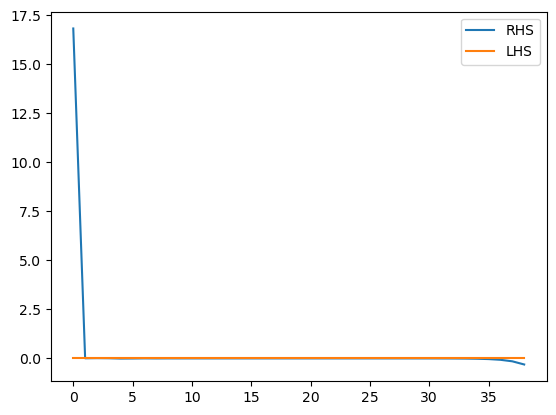

In [94]:
plt.plot(rhs_cut, label='RHS')
plt.plot(lhs_cut, label='LHS')
plt.legend()
plt.show()

In [95]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(rhs_cut.reshape(-1, 1), lhs_cut.reshape(-1, 1))
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: [-5.10177615e-10]
Intercept: [-5.38361759e-08]


TypeError: Invalid shape (101,) for image data

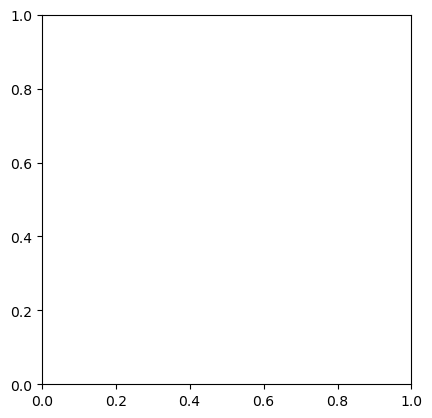

In [96]:
plt.imshow(rhs)

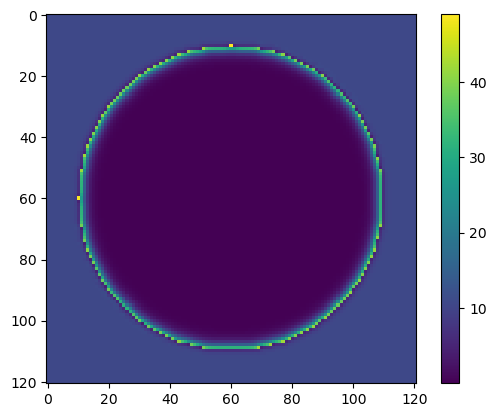

In [ ]:
plt.imshow(lhs)
plt.colorbar()